# Churn Modelling — Classification
 

## Partie 1 : Problem Definition


 
La **classification** est un type d'apprentissage supervisé utilisé pour prédire une catégorie (classe).

Contrairement à la régression (qui prédit une valeur continue), la classification répond à des questions comme :
- « Ce client va-t-il quitter la banque ? »
- « Le client est-il fidèle ou churner ? »
- « Quel est le risque de désabonnement ? »

**Dataset : Churn Modelling**
- Nombre de lignes : 10 000
- Nombre de colonnes : 14 (dont des identifiants, des features et une cible)

**Colonnes à ignorer (non pertinentes) :** RowNumber, CustomerId, Surname

**Variables numériques :** CreditScore, Age, Tenure, Balance, NumOfProducts, EstimatedSalary

**Variables catégorielles :** Geography, Gender

**Variables binaires :** HasCrCard, IsActiveMember

**Variable cible :** Exited (0 = client resté, 1 = client parti)

##### Objectif :
Construire un modèle ML capable de :
- Prédire si un client va quitter la banque (churn)
- Comprendre les facteurs qui influencent le départ des clients
- Aider la banque à identifier les clients à risque et à agir en amont

## Partie 2 : Collection et Exploration des Données

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Churn_Modelling.csv')
print(f"Dataset shape : {df.shape}")
df.head()

Dataset shape : (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [158]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [159]:
# Dimension du dataset
df.shape                       

(10000, 14)

In [160]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [161]:
# Informations générales (types et valeurs nulles)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [162]:
# Valeurs manquantes 
df.isnull().sum() 

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [163]:
# Colonnes catégorielles
df.select_dtypes(exclude='object').columns

Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [164]:
# Colonnes numériques
df.select_dtypes(include='object').columns 

Index(['Surname', 'Geography', 'Gender'], dtype='object')

In [165]:
# Valeurs dupliquées 
df.duplicated().sum() 

np.int64(0)

In [166]:
# Nombre de valeurs uniques par colonne
df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

In [167]:
# Types des colonnes
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [168]:
# Nombre de colonnes par type
df.dtypes.value_counts() 

int64      9
object     3
float64    2
Name: count, dtype: int64

Distribution de la variable cible (Exited) :
Exited
0    7963
1    2037
Name: count, dtype: int64

Exited
0    79.6%
1    20.4%
Name: proportion, dtype: object


C:\Users\HP\AppData\Local\Temp\ipykernel_10064\3056643717.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='Set2')


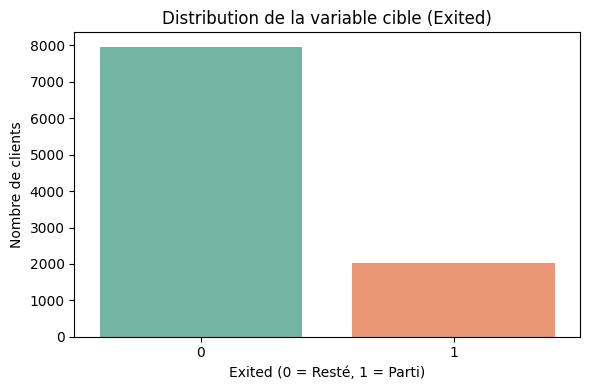

In [169]:
# Distribution de la variable cible ( target )
print("Distribution de la variable cible (Exited) :")
print(df['Exited'].value_counts())
print()
print(df['Exited'].value_counts(normalize=True).map(lambda x: f"{x*100:.1f}%"))

plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='Set2')
plt.title('Distribution de la variable cible (Exited)')
plt.xlabel('Exited (0 = Resté, 1 = Parti)')
plt.ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

 la fonction `value_counts()` sur toutes les colonnes du dataset afin d’analyser la fréquence des valeurs de chaque variable et mieux comprendre la distribution des données.

In [170]:
# Fréquence des valeurs pour les colonnes catégorielles
cat_cols = ['Geography', 'Gender']

for col in cat_cols:
    print(f"Value counts pour {col} :")
    print(df[col].value_counts())
    print("-" * 40)

Value counts pour Geography :
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
----------------------------------------
Value counts pour Gender :
Gender
Male      5457
Female    4543
Name: count, dtype: int64
----------------------------------------


Ce code crée des graphiques pour visualiser la distribution des variables du dataset.

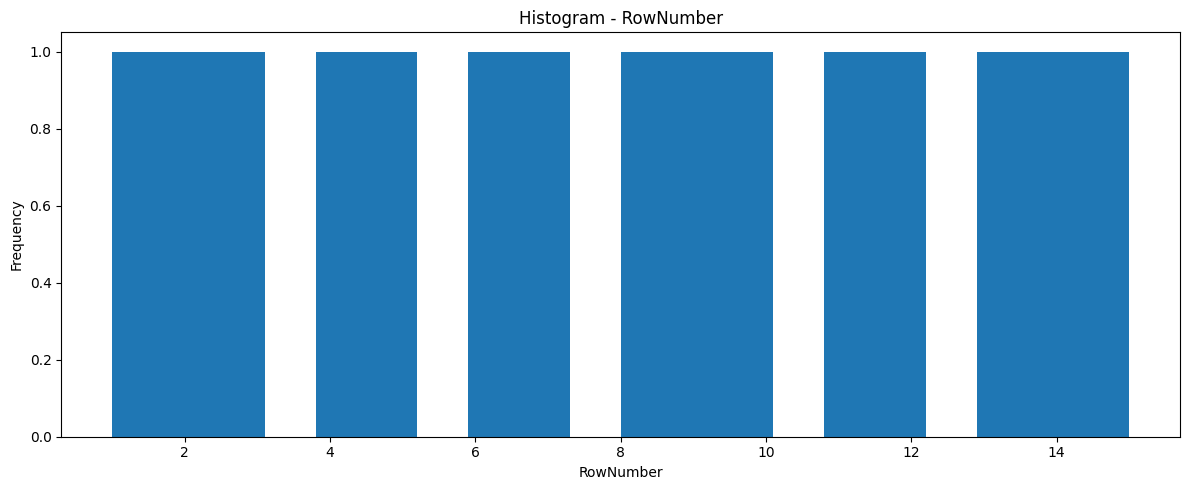

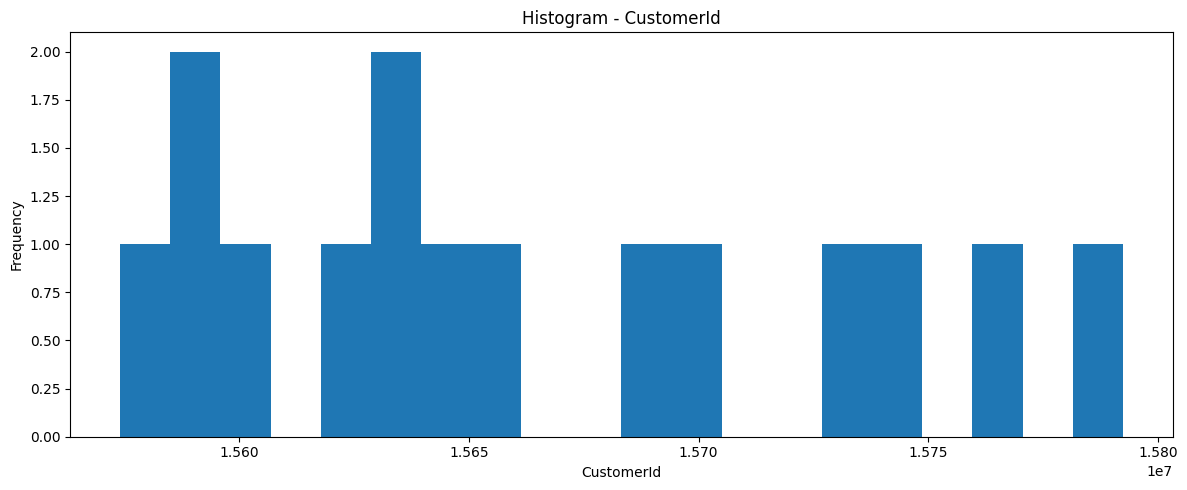

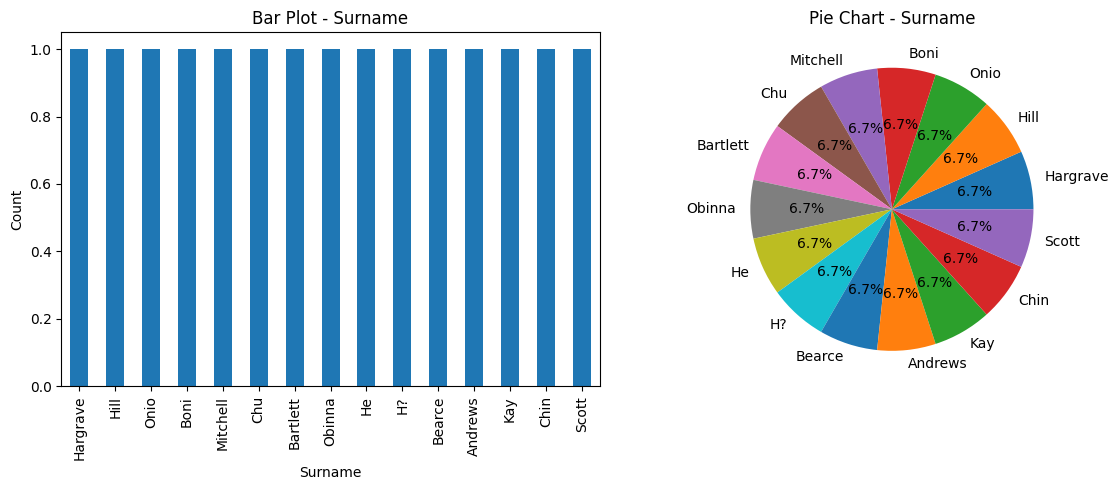

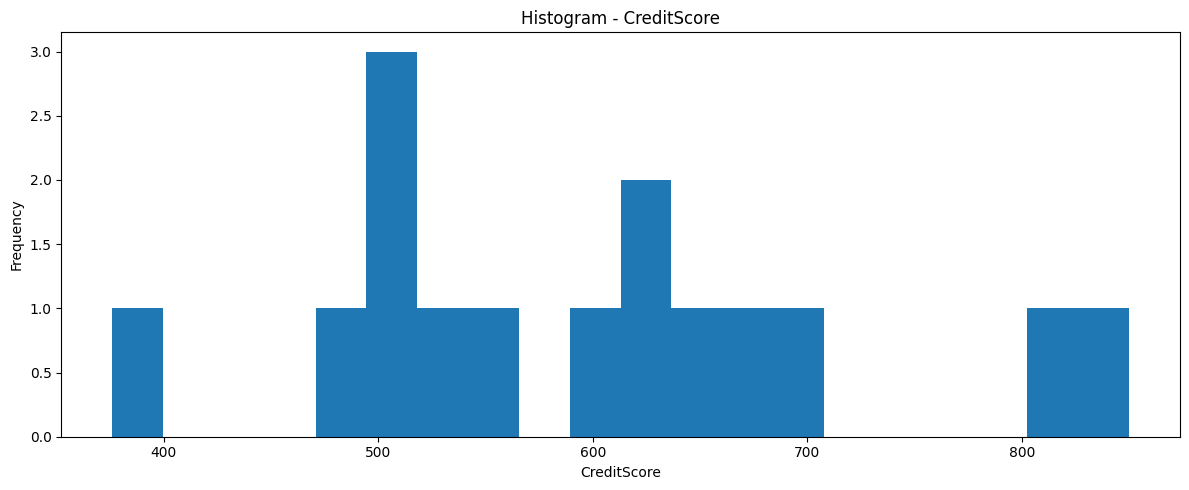

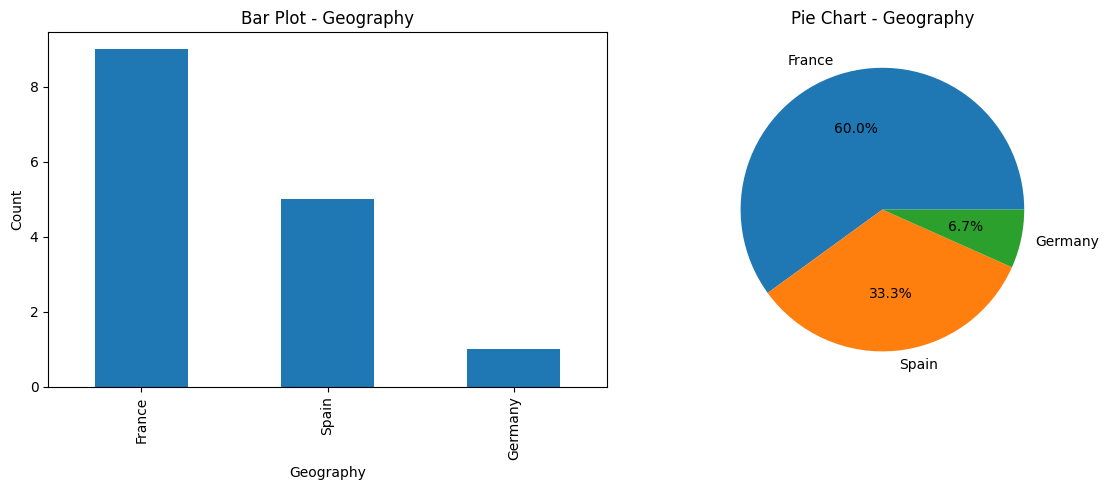

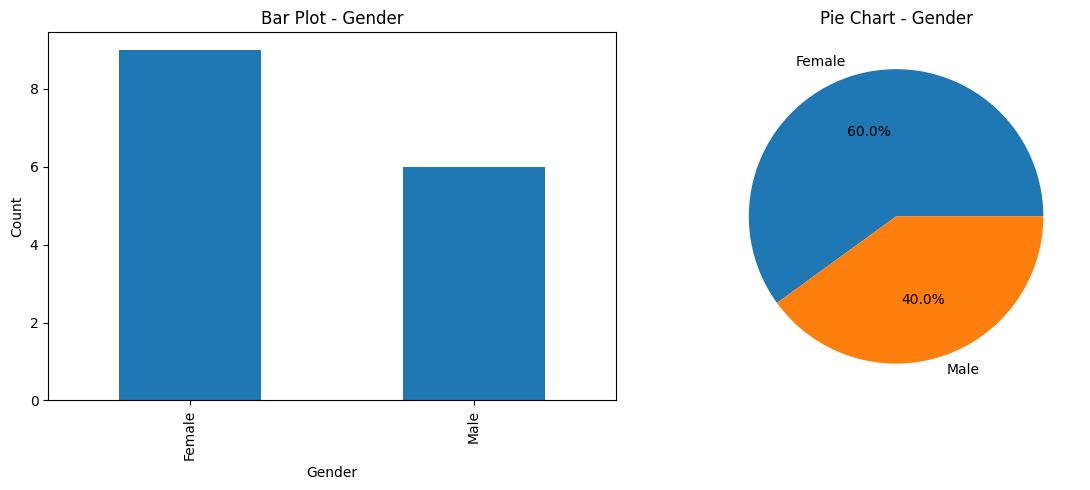

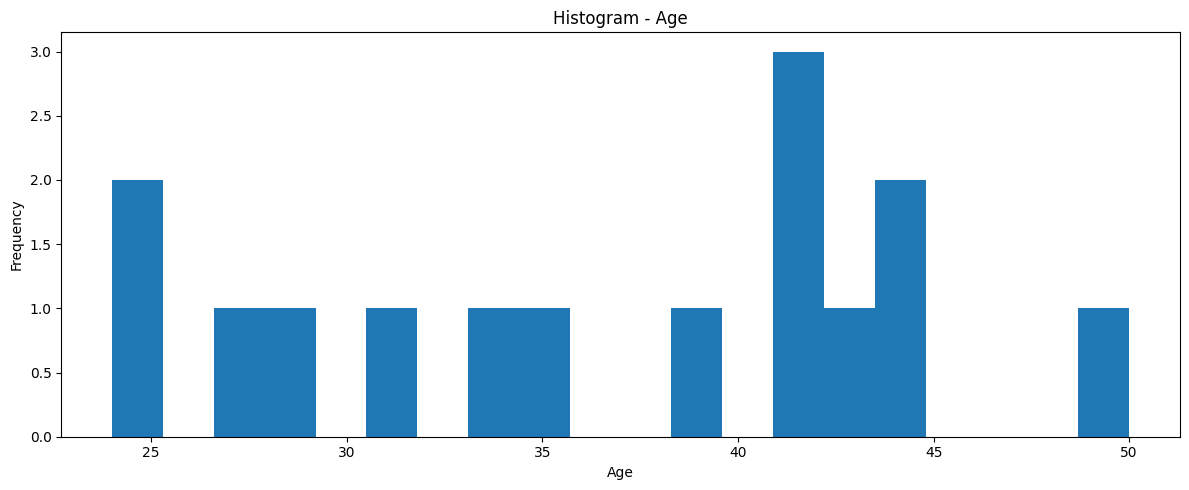

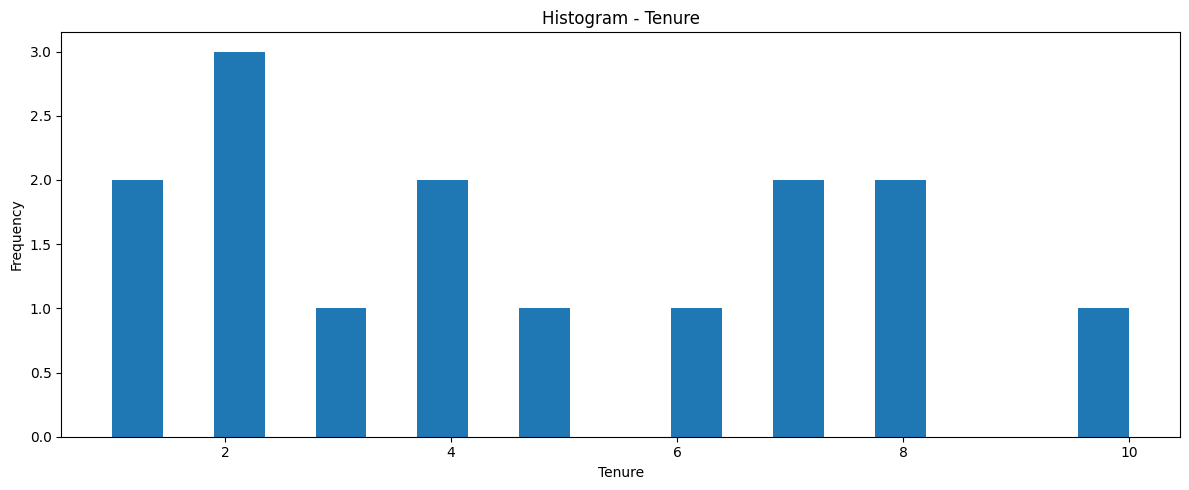

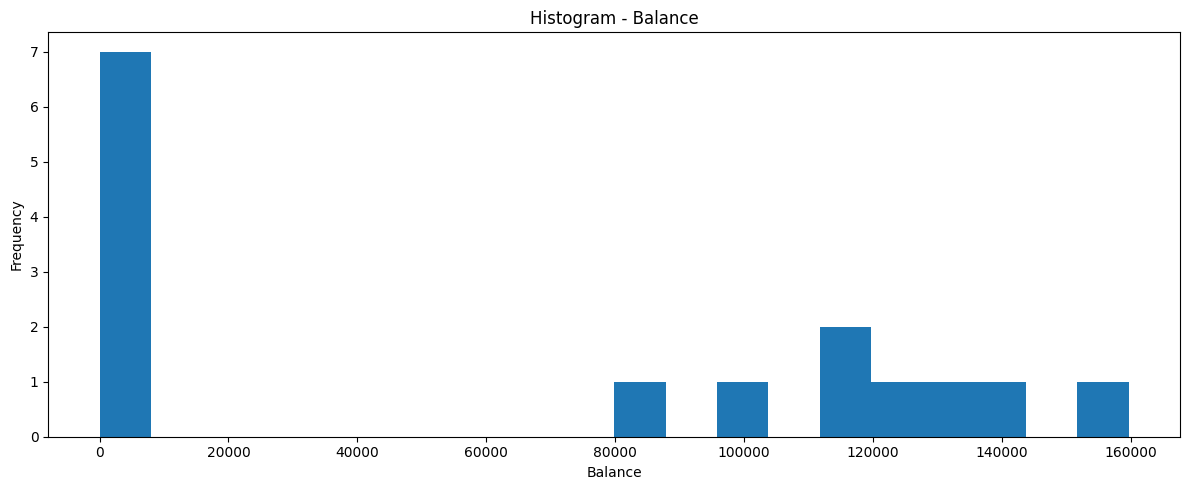

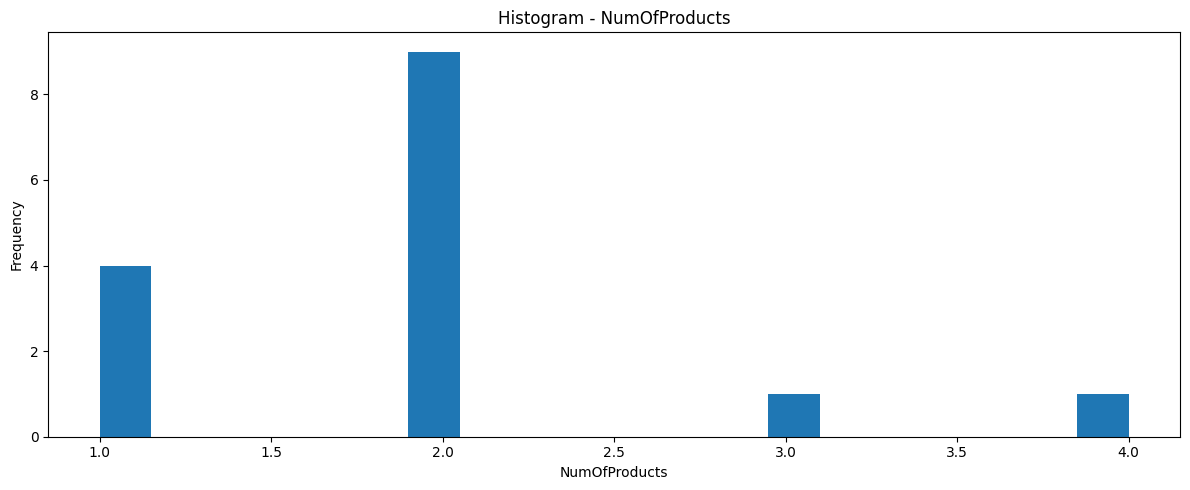

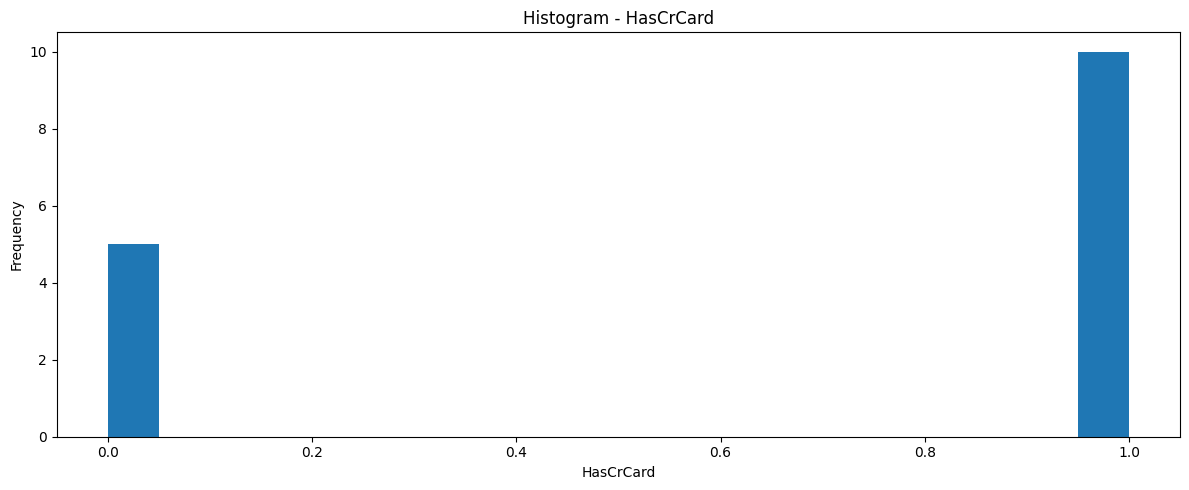

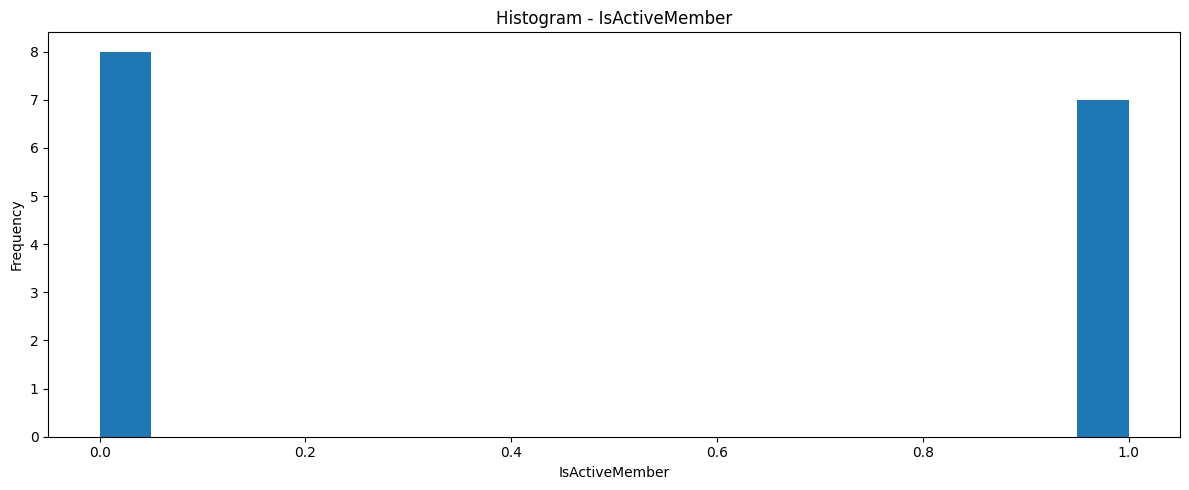

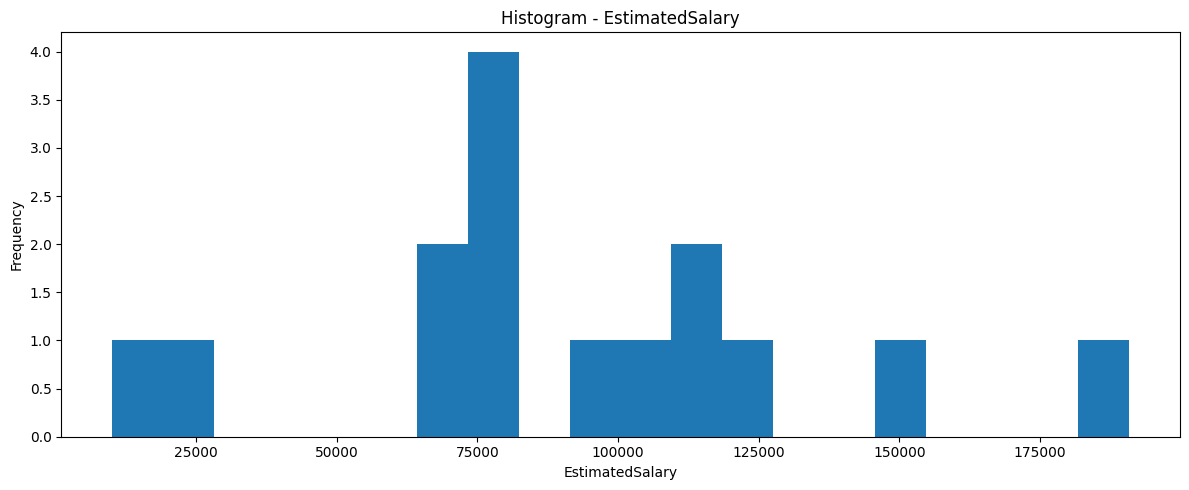

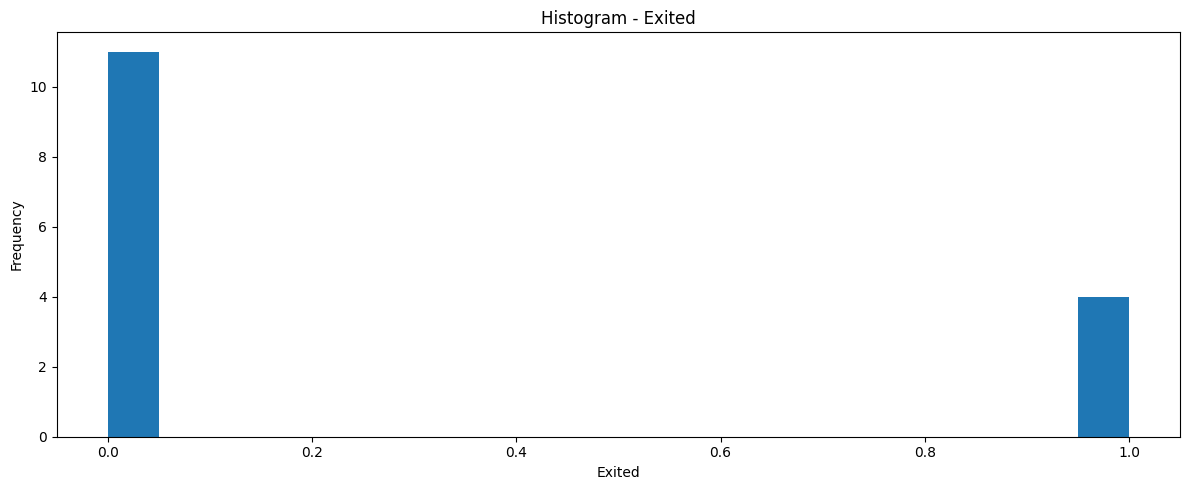

In [171]:
# copie temporaire de 15 lignes
df15 = df.head(15)

for col in df15.columns:
    plt.figure(figsize=(12,5))
    
    if df15[col].dtype == 'object':
        counts = df15[col].value_counts()

        plt.subplot(1,2,1)
        counts.plot(kind='bar')
        plt.title(f'Bar Plot - {col}')
        plt.xlabel(col)
        plt.ylabel('Count')

        plt.subplot(1,2,2)
        counts.plot(kind='pie', autopct='%1.1f%%')
        plt.title(f'Pie Chart - {col}')
        plt.ylabel('')

    else:
        plt.hist(df15[col], bins=20)
        plt.title(f'Histogram - {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

## partie 2 : Data cleaning

 

- Suppression des colonnes inutiles (RowNumber, CustomerId, Surname)
- Vérification et suppression des doublons
- Gestion des valeurs manquantes
- Détection et traitement des outliers (Winsorization)

In [172]:
df.shape 

#  Suppression des colonnes non pertinentes  
# RowNumber, CustomerId, Surname : identifiants qui n'apportent aucune info au modèle

df_clean = df.drop(columns=['RowNumber',  'Surname'] )

print(f"Après suppression des colonnes inutiles : {df.shape}")
df.head()

Après suppression des colonnes inutiles : (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [173]:
# duplicated 
df.duplicated().sum()

np.int64(0)

In [174]:
print("Avant :", df.shape[0])

Avant : 10000


In [175]:
# import numpy as np
# import pandas as pd

# # Fonction pour supprimer les outliers avec la méthode IQR

# def drop_outliers_iqr(df, columns):

#     df_clean = df.copy()

#     for col in columns:

#         # Calcul des quartiles
#         Q1 = df_clean[col].quantile(0.25)
#         Q3 = df_clean[col].quantile(0.75)

#         # Calcul IQR
#         IQR = Q3 - Q1

#         # Limites
#         lower = Q1 - 1.5 * IQR
#         upper = Q3 + 1.5 * IQR

#         # Suppression des outliers
#         df_clean = df_clean[
#             (df_clean[col] >= lower) &
#             (df_clean[col] <= upper)
#         ]

#     return df_clean

In [176]:
# num_cols = [
#     'CreditScore',
#     'Age',
#     'Tenure',
#     'Balance',
#     'NumOfProducts',
#     'EstimatedSalary'
# ]

# df_clean = drop_outliers_iqr(df, num_cols)
 

In [177]:
# print("Après :", df_clean.shape[0])

In [178]:
# print("Lignes supprimées :", df.shape[0] - df_clean.shape[0])

In [179]:
df.shape

(10000, 14)

In [180]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Partie 4 : Data Analyse

 


### Permet de comparer les clients jeunes et âgés Les clients âgés ont généralement un taux de churn plus élevé

In [181]:
# Créer une variable pour distinguer jeunes et âgés
df['AgeCategory'] = (df['Age'] > 40).astype(int)

# Calculer le taux de churn pour chaque catégorie
df.groupby('AgeCategory')['Exited'].mean()

AgeCategory
0    0.106870
1    0.377269
Name: Exited, dtype: float64

### Permet de voir si les clients inactifs avec un solde nul quittent plus

In [182]:
# Comparer le churn selon le solde et l'activité
df.groupby(['Balance','IsActiveMember'])['Exited'].mean()

Balance    IsActiveMember
0.00       0                 0.183486
           1                 0.096103
3768.69    0                 1.000000
12459.19   0                 1.000000
14262.80   0                 0.000000
                               ...   
216109.88  1                 1.000000
221532.80  0                 0.000000
222267.63  0                 1.000000
238387.56  1                 1.000000
250898.09  1                 1.000000
Name: Exited, Length: 6385, dtype: float64

### Analyse l'effet du salaire sur le churn Permet de détecter des tendances par niveau de revenu

In [183]:
# Créer des tranches de salaire
df['SalaryGroup'] = pd.cut(df['EstimatedSalary'], bins=4)

# Calculer le churn par tranche
df.groupby('SalaryGroup')['Exited'].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_10064\2175341710.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('SalaryGroup')['Exited'].mean()


SalaryGroup
(-188.401, 50006.805]      0.199348
(50006.805, 100002.03]     0.198660
(100002.03, 149997.255]    0.202348
(149997.255, 199992.48]    0.214664
Name: Exited, dtype: float64

### Vérifie si les clients anciens et actifs restent fidèles

In [184]:
# Segment des clients fidèles (ancienneté + activité)
loyal_long = df[
    (df['Tenure'] > 5) &
    (df['IsActiveMember'] == 1)
]

loyal_long['Exited'].mean()

np.float64(0.13550373955125386)

### Permet d’observer le comportement des clients avec différents nombres de produits

In [185]:
# Clients avec beaucoup ou peu de produits
df.groupby('NumOfProducts')['Exited'].count()
df.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

### Permet de détecter des différences de comportement selon le genre et l'activité

In [186]:
# Analyse combinée genre et activité
df.groupby(['Gender','IsActiveMember'])['Exited'].mean()

Gender  IsActiveMember
Female  0                 0.320938
        1                 0.181261
Male    0                 0.222780
        1                 0.111964
Name: Exited, dtype: float64

### Compare le churn entre les extrêmes de salaire

In [187]:
# Clients avec salaire très élevé
df[df['EstimatedSalary'] > 150000]['Exited'].mean()

# Clients avec salaire faible
df[df['EstimatedSalary'] < 50000]['Exited'].mean()

np.float64(0.1993477374643294)

### Permet d’identifier un segment critique de clients

In [188]:

segment = df[
    (df['Age'] > 50) &
    (df['IsActiveMember'] == 0) &
    (df['Balance'] > 0)
]


segment['Exited'].mean()

np.float64(0.8584905660377359)

### Compare les caractéristiques moyennes des deux groupes

In [189]:
# Moyenne des variables pour churn vs non churn
df.groupby('Exited')[['Age','Balance','EstimatedSalary','CreditScore']].mean()

,Age,Balance,EstimatedSalary,CreditScore
Exited,,,,
0,37.408389,72745.296779,99738.391772,651.853196
1,44.837997,91108.539337,101465.677531,645.351497


### Permet une analyse plus précise que les tranches fixes Compare le churn entre les 25% les plus jeunes et les plus âgés

In [190]:
# Diviser l'âge en quartiles
df['AgeQuartile'] = pd.qcut(df['Age'], q=4)

# Taux de churn par quartile
df.groupby('AgeQuartile')['Exited'].mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_10064\3981268361.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeQuartile')['Exited'].mean()


AgeQuartile
(17.999, 32.0]    0.076344
(32.0, 37.0]      0.108402
(37.0, 44.0]      0.206374
(44.0, 92.0]      0.446154
Name: Exited, dtype: float64

In [191]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeCategory,SalaryGroup,AgeQuartile
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,"(100002.03, 149997.255]","(37.0, 44.0]"
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,"(100002.03, 149997.255]","(37.0, 44.0]"
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,"(100002.03, 149997.255]","(37.0, 44.0]"
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,"(50006.805, 100002.03]","(37.0, 44.0]"
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1,"(50006.805, 100002.03]","(37.0, 44.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,"(50006.805, 100002.03]","(37.0, 44.0]"
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,"(100002.03, 149997.255]","(32.0, 37.0]"
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0,"(-188.401, 50006.805]","(32.0, 37.0]"
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,"(50006.805, 100002.03]","(37.0, 44.0]"


In [192]:
# Supprimer les colonnes category

df = df.drop(columns=['SalaryGroup', 'AgeQuartile'])

# Vérification
print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
AgeCategory          int64
dtype: object


In [193]:
df = df.drop(columns=['RowNumber' , 'Surname'])

In [194]:
df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True
)

## Partie 5 : Data Preprocessing


 
### Étapes :
1. **Encoding** des variables catégorielles (One-Hot Encoding)
2. **Séparation** X / y
3. **Train/Test Split** avec `stratify` (pour garder la même distribution)
4. **Balancing des données** avec **SMOTE**
5. **Scaling** avec StandardScaler
 

### Pourquoi SMOTE ?

Le dataset est **déséquilibré** :
- Classe 0 (Resté) : **79.6%** des clients
- Classe 1 (Parti)  : **20.4%** des clients

Sans correction, le modèle apprend surtout à prédire la classe majoritaire (0) et ignore la minoritaire (1), ce qui donne une fausse bonne accuracy.

**SMOTE** (Synthetic Minority Oversampling Technique) crée de nouvelles données synthétiques pour la classe minoritaire en interpolant entre les voisins les plus proches — sans dupliquer bêtement les exemples.

>   SMOTE s'applique **uniquement sur le train set**, jamais sur le test set.

In [195]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

#  Encoding des variables catégorielles (One-Hot Encoding) 
# Geography (France/Spain/Germany) → 3 colonnes binaires
# Gender (Male/Female)             → 2 colonnes binaires
# drop_first=True évite la multicolinéarité

df_encoded = pd.get_dummies(
    df_clean,
    columns=['Geography', 'Gender'],
    drop_first=True
)

print(df_encoded.columns)
 

Index(['CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male'],
      dtype='object')


In [196]:
#  Séparation X / y  
X = df_encoded.drop(columns=['Exited'])
y = df_encoded['Exited']

 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'\nColonnes finales : {X.columns.tolist()}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')     


Colonnes finales : ['CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
X_train: (8000, 12), X_test: (2000, 12)


In [197]:
# verification : 

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 12)
X_test: (2000, 12)
y_train: (8000,)
y_test: (2000,)


In [198]:
# --- Feature Engineering ---

# Ratio Features
df["balance_salary_ratio"] = df["Balance"] / (df["EstimatedSalary"] + 1)
df["credit_age_ratio"] = df["CreditScore"] / (df["Age"] + 1)
df["tenure_by_age"] = df["Tenure"] / (df["Age"] + 1)

# Polynomial / Interaction Features
df["balance_product"] = df["Balance"] * df["NumOfProducts"]
df["credit_active"] = df["CreditScore"] * df["IsActiveMember"]

# Binning Age
df["AgeGroup"] = pd.cut(df["Age"], bins=[18, 30, 50, 100], labels=["Young", "Middle", "Old"])

# Binning Salary
df["SalaryBin"] = pd.cut(df["EstimatedSalary"], bins=3, labels=["Low", "Medium", "High"])

# One-Hot Encoding
# df = pd.get_dummies(df, columns=["Geography", "Gender", "AgeGroup", "SalaryBin"], drop_first=True)


In [ ]:
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features et target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split
X_train, X_test, y_train, y_test = train_test_split( X, y,  stratify=y  )

# # # Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 

In [ ]:
# SMOTEENN
smoteenn = SMOTEENN(random_state=42)

X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(
    X_train ,
    y_train
)

# Vérification
print("Avant SMOTEENN :")
print(y_train.value_counts())

print("\nAprès SMOTEENN :")
print(pd.Series(y_train_smoteenn).value_counts())

Avant SMOTEENN :
Exited
0    5972
1    1528
Name: count, dtype: int64

Après SMOTEENN :
Exited
1    3408
0    2480
Name: count, dtype: int64


In [ ]:
#   Scaling : StandardScaler  
# fit() sur train uniquement = transform() sur test
# Évite toute fuite d'information (data leakage)
  
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled  shape : {X_test_scaled.shape}")


X_train_scaled shape : (7500, 13)
X_test_scaled  shape : (2500, 13)


In [ ]:
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

 

### Modèles entraînés :
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Support Vector Machine (SVM)

### Métriques d'évaluation :
- **Accuracy** : % de bonnes prédictions
- **Precision** : parmi les prédits churners, combien le sont vraiment
- **Recall** : parmi les vrais churners, combien sont détectés
- **F1-Score** : équilibre entre Precision et Recall
- **ROC-AUC** : capacité du modèle à distinguer les deux classes

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

# Fonction pour évaluer un modèle de classification
def evaluate_classifier(name, model, X_test_data, y_test_data):

    # Faire les prédictions
    y_pred = model.predict(X_test_data)

    # Probabilités pour la courbe ROC
    y_proba = model.predict_proba(X_test_data)[:, 1]

    # Afficher Accuracy et F1-score
    print(f" {name} ")
    print(f"Accuracy: {accuracy_score(y_test_data, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test_data, y_pred):.4f}")

    # Afficher le rapport de classification
    print("\nClassification Report:")
    print(classification_report(
        y_test_data,
        y_pred,
        target_names=['No Disease', 'Disease']
    ))

    # Créer 2 graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Matrice de confusion 
    mc= confusion_matrix(y_test_data, y_pred)

    sns.heatmap( mc, annot=True, fmt="d", cmap="Blues",
        xticklabels=['No Disease', 'Disease'],
        yticklabels=['No Disease', 'Disease'], ax=axes[0] ) 
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f"{name} - Confusion Matrix")


    #  Courbe ROC 
    fpr, tpr, _ = roc_curve(y_test_data, y_proba) 
    # Calcul du score AUC
    roc_auc = auc(fpr, tpr) 
    # Tracer la courbe ROC
    axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')

    # Ligne de référence
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5) 
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} - ROC Curve')

    # Afficher la légende
    axes[1].legend(loc='lower right')

    # Ajuster l'affichage
    plt.tight_layout()
    plt.show()

    # Retourner les prédictions
    return y_pred, y_proba

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
 
from sklearn.linear_model import LogisticRegression   
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc 

# entrainnement 
logreg = LogisticRegression( 
        fit_intercept=True, 
        C=1, 
        penalty="l2", 
        solver="newton-cg", 
        random_state=42 
        )

logreg.fit(X_train_scaled, y_train)  # train the model 



c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` pro

In [ ]:
# evaluation
y_pred_lr = logreg.predict(X_test_scaled)

print("Logistic Regression performance : ")
print(f" Accuracy :{accuracy_score(y_test , y_pred_lr) } ")
print(f" f1_score :{f1_score(y_test , y_pred_lr) } ") 

Logistic Regression performance : 
 Accuracy :0.822 
 f1_score :0.36428571428571427 


 LogisticRegression 
Accuracy: 0.8220
F1 Score : 0.3643

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.96      0.90      1607
     Disease       0.61      0.26      0.36       393

    accuracy                           0.82      2000
   macro avg       0.73      0.61      0.63      2000
weighted avg       0.80      0.82      0.79      2000



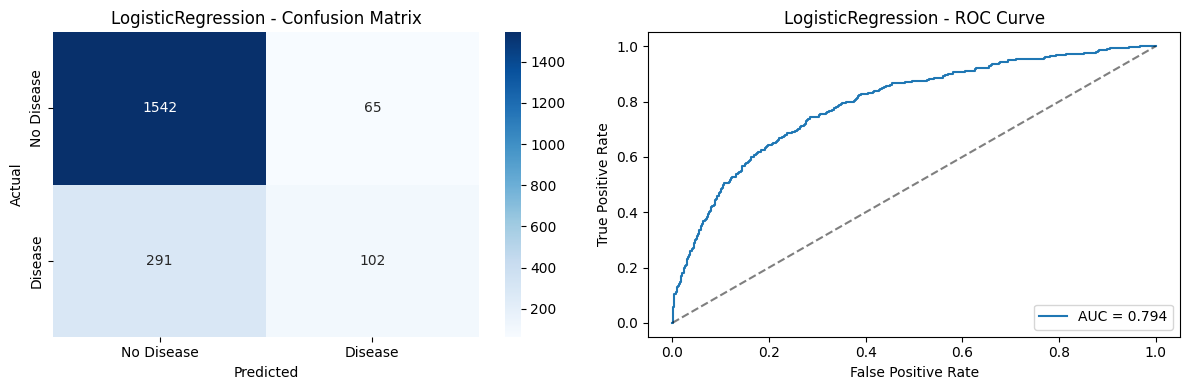

In [ ]:
y_pred_lr, y_proba_lr = evaluate_classifier('LogisticRegression', logreg, X_test_scaled, y_test)

###  Modèle 2 — K-Nearest Neighbors (KNN)

 KNN 
Accuracy: 0.8485
F1 Score : 0.4958

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.86      0.96      0.91      1607
     Disease       0.72      0.38      0.50       393

    accuracy                           0.85      2000
   macro avg       0.79      0.67      0.70      2000
weighted avg       0.83      0.85      0.83      2000



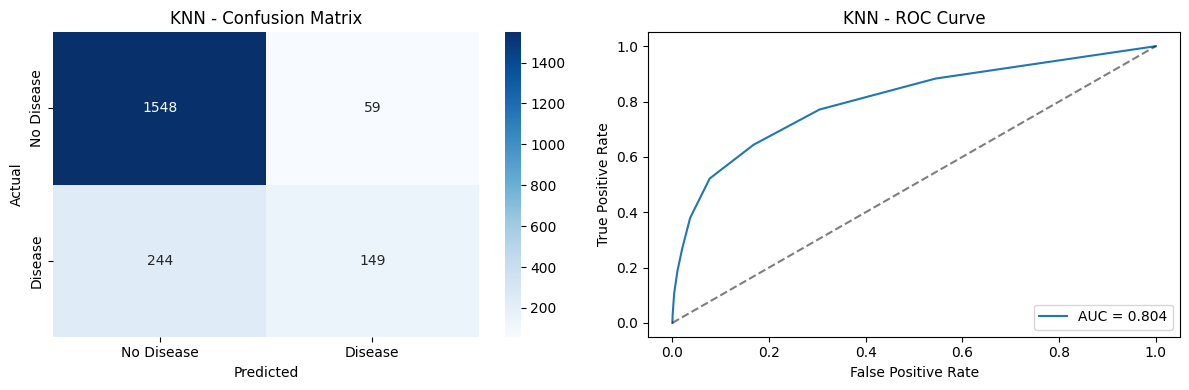

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# entrainnement (train the model )
knn = KNeighborsClassifier(metric="manhattan", n_neighbors=9, algorithm="ball_tree")
knn.fit(X_train_scaled, y_train)

# evaluation
y_pred_knn, y_proba_knn = evaluate_classifier("KNN", knn, X_test_scaled, y_test)

### Modèle 3 — Decision Tree

 Decision Tree 
Accuracy: 0.8430
F1 Score : 0.5462

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.88      0.93      0.91      1607
     Disease       0.63      0.48      0.55       393

    accuracy                           0.84      2000
   macro avg       0.76      0.71      0.73      2000
weighted avg       0.83      0.84      0.83      2000



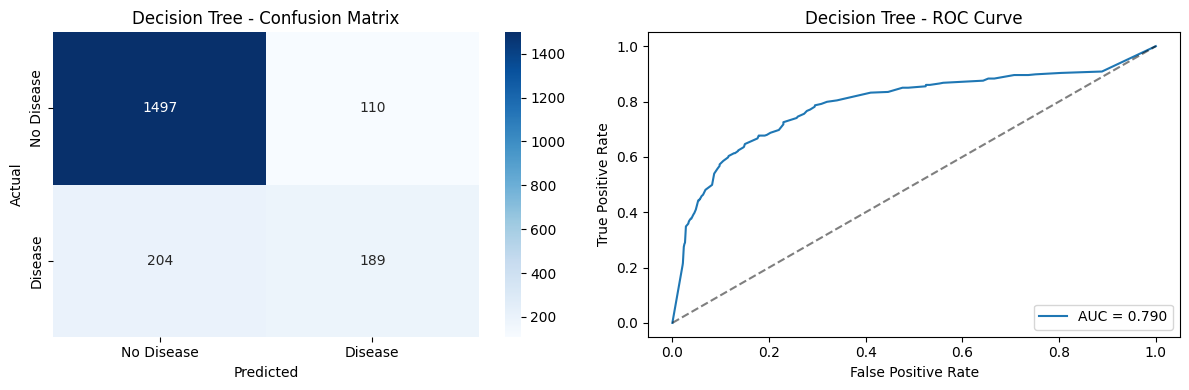

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# entrainnement (train the model )
dt = DecisionTreeClassifier(criterion="gini", max_depth=10, random_state=42, min_samples_split=10 )
dt.fit(X_train_scaled, y_train)

# evaluation
y_pred_dt, y_proba_dt = evaluate_classifier("Decision Tree", dt, X_test_scaled, y_test)

### Modèle 4 — Random Forest  

 Random Forest 
Accuracy: 0.8680
F1 Score : 0.5875

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.88      0.96      0.92      1607
     Disease       0.76      0.48      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



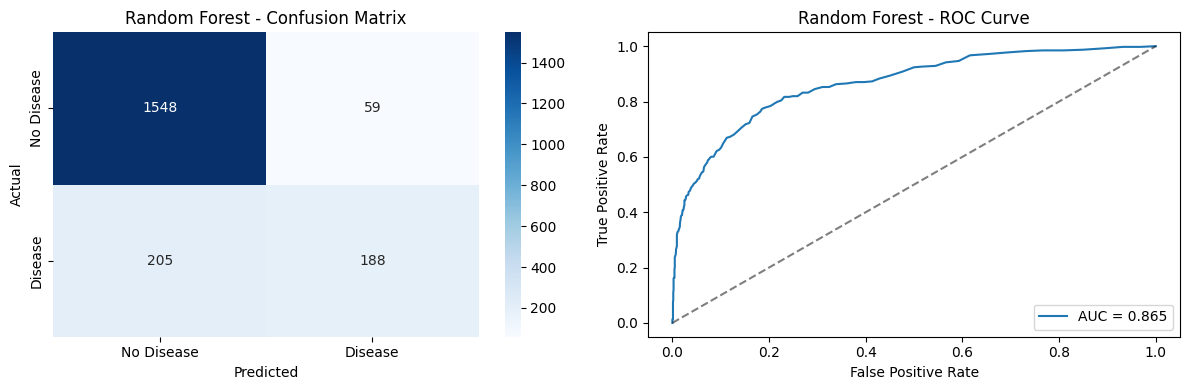

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# entrainnement (train the model )
rf = RandomForestClassifier(n_estimators=150,criterion="gini", max_depth=70, random_state=42 )
rf.fit(X_train_scaled, y_train)

# evaluation
y_pred_rf, y_proba_rf = evaluate_classifier("Random Forest", rf, X_test_scaled, y_test)

### Modèle 5 — Support Vector Classifier (SVC)

 SVC 
Accuracy: 0.7795
F1 Score : 0.5577

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.92      0.80      0.85      1607
     Disease       0.46      0.71      0.56       393

    accuracy                           0.78      2000
   macro avg       0.69      0.75      0.71      2000
weighted avg       0.83      0.78      0.80      2000



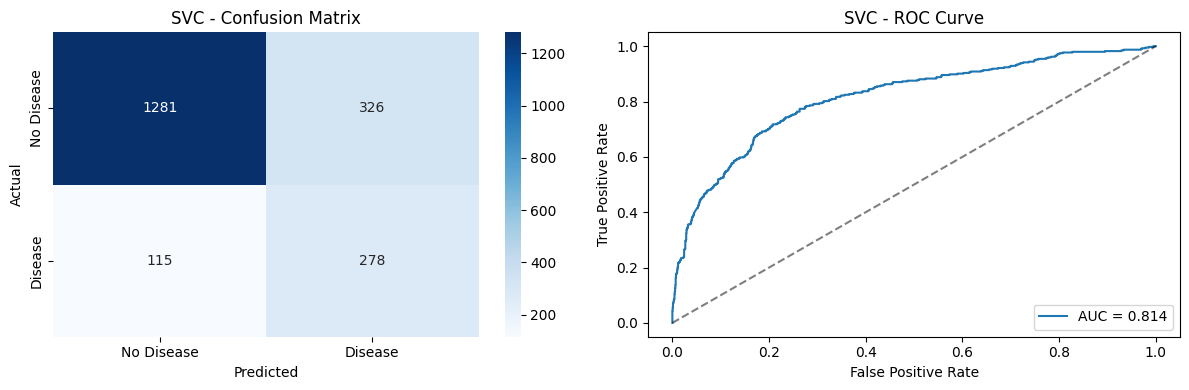

In [ ]:
# from sklearn.svm import SVC

# # entrainnement (train the model )
# svc = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
# svc.fit(X_train_scaled, y_train)

# # evaluation
# y_pred_svc, y_proba_svc = evaluate_classifier("SVC", svc, X_test_scaled, y_test)

from sklearn.svm import SVC

# entraînement
svc = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    probability=True   # IMPORTANT
)

svc.fit(X_train_scaled, y_train)

# évaluation
y_pred_svc, y_proba_svc = evaluate_classifier(
    "SVC",
    svc,
    X_test_scaled,
    y_test
)

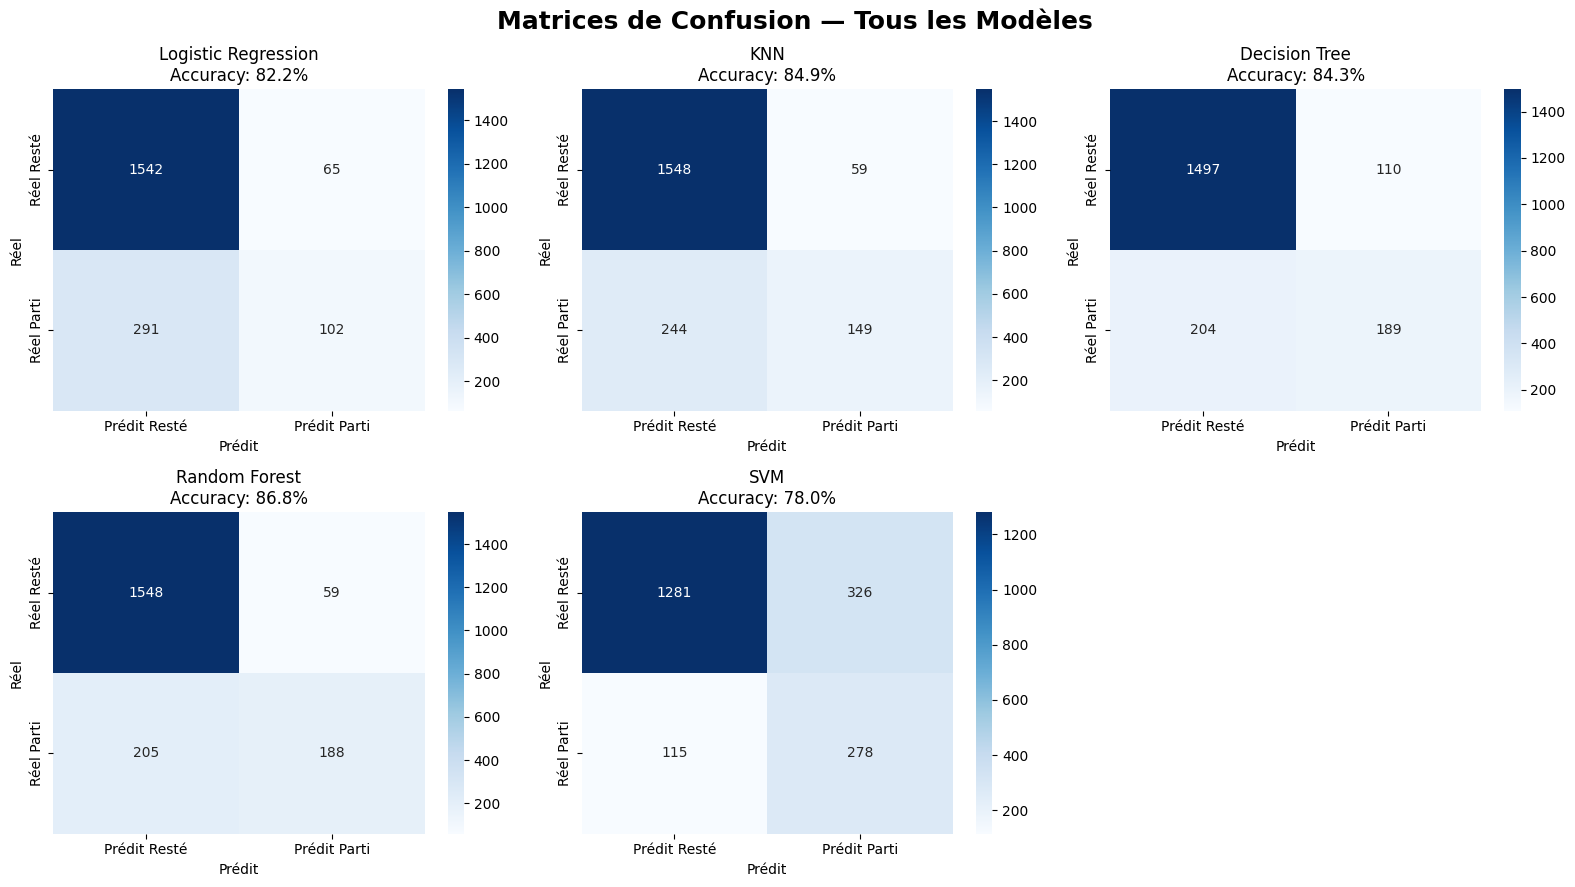

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des modèles
models = {
    "Logistic Regression": logreg,
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svc
}

# Création de la figure
plt.figure(figsize=(16, 9))

# Boucle sur les modèles
for i, (name, model) in enumerate(models.items(), 1):

    # Prédictions
    y_pred = model.predict(X_test_scaled)

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Subplot
    plt.subplot(2, 3, i)

    # Heatmap
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    # Titres
    plt.title(f"{name}\nAccuracy: {acc:.1%}")

    # Labels axes
    plt.xlabel("Prédit")
    plt.ylabel("Réel")

    # Labels personnalisés
    plt.xticks([0.5, 1.5], ["Prédit Resté", "Prédit Parti"])
    plt.yticks([0.5, 1.5], ["Réel Resté", "Réel Parti"], rotation=90)

# Titre général
plt.suptitle("Matrices de Confusion — Tous les Modèles",
             fontsize=18,
             fontweight='bold')

plt.tight_layout()
plt.show()

## Partie 7 : Models Comparaison

In [ ]:
# Liste des modèles
models = [
    "Logistic Regression",
    "KNN",
    "Decision Tree",
    "Random Forest",
    "SVC"
]

# Accuracy de chaque modèle
accuracy_scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svc)
]

# F1-Score de chaque modèle
f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_svc)
]

# Création du DataFrame de comparaison
comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy_scores,
    "F1 Score": f1_scores
})

# Affichage des résultats
print("\nModel Comparison:\n")
print(comparison_df)


Model Comparison:

                 Model  Accuracy  F1 Score
0  Logistic Regression    0.8220  0.364286
1                  KNN    0.8485  0.495840
2        Decision Tree    0.8430  0.546243
3        Random Forest    0.8680  0.587500
4                  SVC    0.7795  0.557673


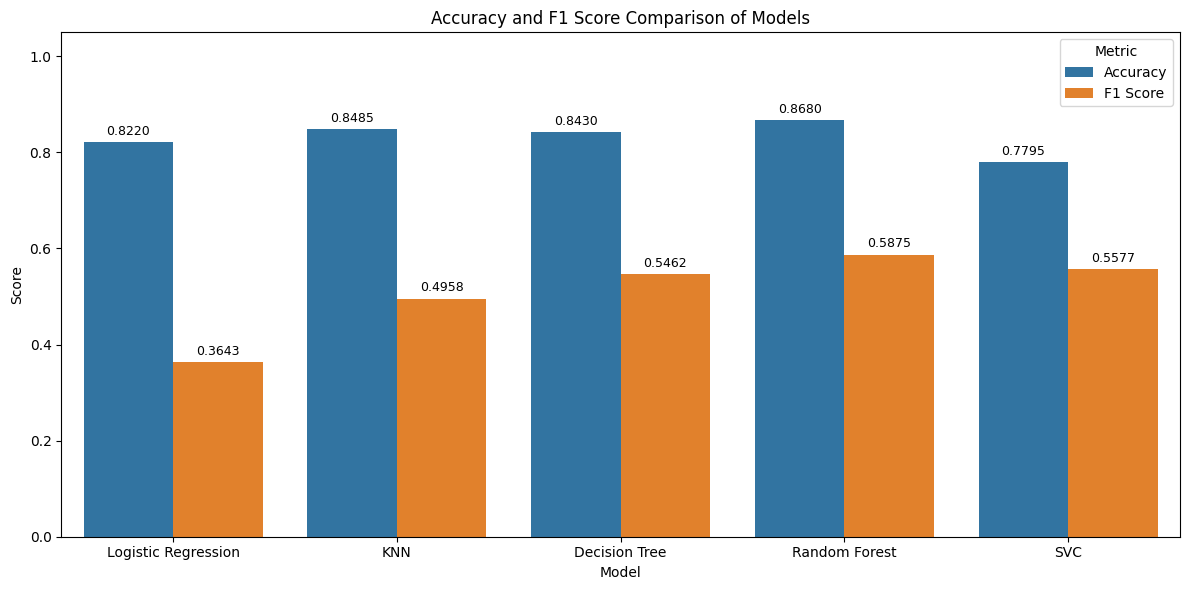

In [ ]:
# Grouped bar plot for Accuracy and F1 Score comparison

# Transformer les données
melted = comparison_df.melt( id_vars='Model', value_vars=['Accuracy', 'F1 Score'],
                            var_name='Metric', value_name='Score' )

# Taille du graphique
plt.figure(figsize=(12, 6))

# Créer le graphique
ax = sns.barplot( x='Model', y='Score', hue='Metric', data=melted ) 
plt.title('Accuracy and F1 Score Comparison of Models')
plt.ylabel('Score') 
plt.ylim(0, 1.05)

# Ajouter les valeurs sur les barres
for container in ax.containers:
    ax.bar_label( container, fmt='%.4f', padding=3, fontsize=9 )
 
plt.legend(title='Metric') 
plt.tight_layout() 
plt.show()

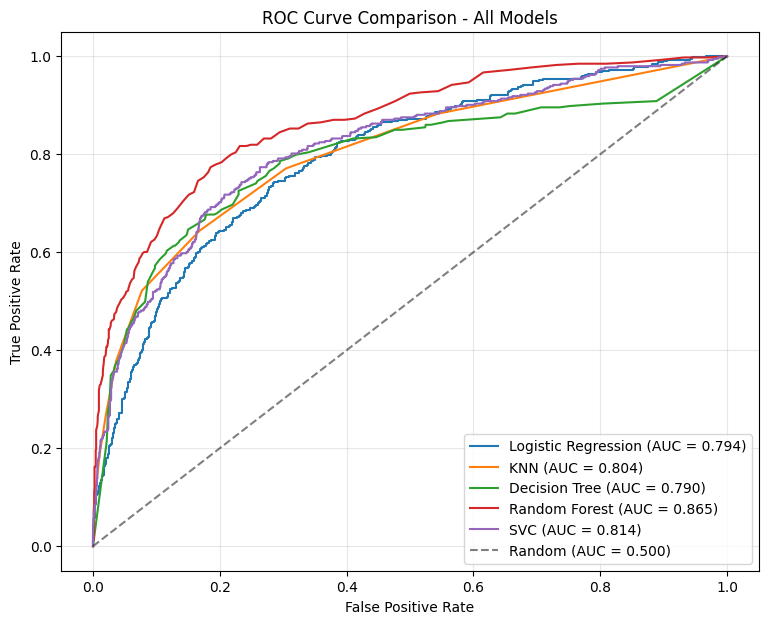

In [ ]:
# Combined ROC curves - all models on a single plot

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt 

plt.figure(figsize=(9, 7)) 
# Dictionnaire des modèles entraînés
trained_models = {
    'Logistic Regression': logreg,
    'KNN': knn,
    'Decision Tree': dt,
    'Random Forest': rf,
    'SVC': svc
} 

for name, model in trained_models.items():

    # Probabilités pour ROC
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calcul ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    # Calcul AUC
    roc_auc = auc(fpr, tpr)

    # Tracer la courbe
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
 
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.500)')
 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models') 
plt.legend(loc='lower right') 
plt.grid(alpha=0.3) 
plt.show()

In [ ]:
best_model = comparison_df.loc[comparison_df["F1 Score"].idxmax()]
best_model 

Model       Random Forest
Accuracy            0.868
F1 Score           0.5875
Name: 3, dtype: object

In [ ]:

comparison_df.loc[comparison_df["Accuracy"].idxmax()]

Model       Random Forest
Accuracy            0.868
F1 Score           0.5875
Name: 3, dtype: object

###  Cross Validation 

### Pourquoi la Cross Validation ?

Quand on évalue un modèle avec un seul `train_test_split`, le résultat dépend **du hasard** : selon comment les données sont découpées, le score peut être trop optimiste ou trop pessimiste.

> La **Cross Validation** permet d'évaluer le modèle de manière **plus fiable et plus robuste**, en testant sur plusieurs sous-ensembles différents.

### K-Fold Cross Validation (cv=5)

```
Fold 1 : [TEST] [train] [train] [train] [train]  → score 1
Fold 2 : [train] [TEST] [train] [train] [train]  → score 2
Fold 3 : [train] [train] [TEST] [train] [train]  → score 3
Fold 4 : [train] [train] [train] [TEST] [train]  → score 4
Fold 5 : [train] [train] [train] [train] [TEST]  → score 5

Score final = moyenne(score1, score2, score3, score4, score5)
```

#### Avantages :
- Réduit le risque de sur-apprentissage (overfitting)
- Utilise toutes les données pour l'entraînement et le test
- Donne une estimation plus stable des performances

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state =42,stratify=y)

In [ ]:
# cross validation compare models using 5 folds cross validation (f1 score)
from sklearn.model_selection import cross_val_score

# Création d’un dictionnaire vide
cv_results = {}


#zip : permet de regrouper plusieurs listes élément par élément
for model, name in zip([logreg, knn, dt, rf, svc], models):

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='f1'
    )

    cv_results[name] = scores
 
    print(f"{name} CV F1 mean : {scores.mean(): }\n")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in

Logistic Regression CV F1 mean :  0.0

KNN CV F1 mean :  0.039726848986008964

Decision Tree CV F1 mean :  0.028911036249150295

Random Forest CV F1 mean :  0.0

SVC CV F1 mean :  0.27331276057833737



In [ ]:
# cross validation compare models using 5 folds cross validation (f1 score)
from sklearn.model_selection import cross_val_score

cv_results = {}

for model, name in zip([logreg, knn, dt, rf, svc], models):

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_results[name] = scores
 
    print(f"{name} CV accuracy mean : {scores.mean(): }\n")

Logistic Regression CV accuracy mean :  0.79625



c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in

KNN CV accuracy mean :  0.782875

Decision Tree CV accuracy mean :  0.782625

Random Forest CV accuracy mean :  0.7955

SVC CV accuracy mean :  0.5625



## Partie 8 : Prédiction sur Nouvelles Données

In [ ]:
# inputs (suppression de target)
df.drop(columns="Exited").head(1)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,AgeCategory,Geography_Germany,Geography_Spain,Gender_Male
0,15634602,619,42,2,0.0,1,1,1,101348.88,1,False,False,False


In [ ]:
X_train.head(1) # incoding 

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,AgeCategory,Geography_Germany,Geography_Spain,Gender_Male
2151,15588614,753,57,7,0.0,1,1,0,159475.08,1,False,False,True


In [ ]:
# scailing
X_train_scaled[1] # donnee d'entrainement apres scaling

array([ 1.05381124, -0.20389777,  0.29493847, -0.3483691 ,  0.69683765,
        0.80843615,  0.64920267,  0.97481699,  1.6612541 ,  1.34425353,
        1.72572313, -0.57638802,  0.91324755])

In [ ]:
# prediction on new data 
new_client = {
    'CreditScore'    : 600,
    'Age'            : 42,
    'Tenure'         : 3,
    'Balance'        : 60000.0,
    'NumOfProducts'  : 2,
    'HasCrCard'      : 1,
    'IsActiveMember' : 1,
    'EstimatedSalary': 50000.0,
    'Geography_Germany': 0,  # France=0,0 | Spain=0,1 | Germany=1,0
    'Geography_Spain'  : 0,
    'Gender_Male'      : 0   # Female=0 | Male=1
}

# CONVERT TO DATAFRAME 
new_df = pd.DataFrame([new_client])

# SCALING
new_df_scaled = scaler.transform(new_df)

display(new_df_scaled)

# PREDICTION
prediction_class = rf.predict(new_df_scaled)
prediction_proba = rf.predict_proba(new_df_scaled)

label = 'CHURN (client va partir) !' if prediction_class[0] == 1 else 'Client va rester'

print(f"Classe Prédit : {prediction_class[0]} ({label})")
print(f"Probabilités : {prediction_proba[0]}")

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- AgeCategory
- CustomerId


## Partie 9 : Save the Best Model
 

In [ ]:
comparison_df

In [ ]:
import joblib

# Sauvegarder le meilleur modèle et le scaler
joblib.dump(rf,     'Best_model_churn.pkl')
joblib.dump(scaler, 'scaler_churn.pkl')
 

In [ ]:
loaded_rf = joblib.load("Best_model_churn.pkl")
loaded_scaler = joblib.load("scaler_churn.pkl")


new_client = {
    'CreditScore'    : 600,
    'Age'            : 42,
    'Tenure'         : 3,
    'Balance'        : 60000.0,
    'NumOfProducts'  : 2,
    'HasCrCard'      : 1,
    'IsActiveMember' : 1,
    'EstimatedSalary': 50000.0,
    'Geography_Germany': 0,  # France=0,0 | Spain=0,1 | Germany=1,0
    'Geography_Spain'  : 0,
    'Gender_Male'      : 0   # Female=0 | Male=1
}


# CONVERT TO DATAFRAME 
new_df = pd.DataFrame([new_client])

# SCALING
new_df_scaled = scaler.transform(new_df)

loaded_rf.predict(new_df_scaled)